In [10]:
#import lib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import copy


In [2]:
#data
data=pd.read_csv("jena.csv")
print(data.columns)

Index(['Date Time', 'p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)',
       'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)',
       'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)',
       'wd (deg)'],
      dtype='str')


In [6]:
#select features
feature_cols = [
    'p (mbar)',
    'rh (%)',
    'wv (m/s)',
    'max. wv (m/s)',
    'wd (deg)',
    'Tdew (degC)',
    'VPact (mbar)',
    'rho (g/m**3)'
]

target_col = 'T (degC)'

data = data[feature_cols + [target_col]].copy()
data = data.dropna()


In [11]:
#settings model
SEQ_LENGTH = 24
BATCH_SIZE = 64
EPOCHS = 30
LEARNING_RATE = 0.001
HIDDEN_SIZE = 64
NUM_LAYERS = 2
DROPOUT = 0.2
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [12]:
#scaling
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

features_scaled = feature_scaler.fit_transform(data[feature_cols])
target_scaled = target_scaler.fit_transform(data[[target_col]])


In [13]:
#sequencing
def create_sequences(features, target, seq_length):
    X, y = [], []
    for i in range(len(features) - seq_length):
        X.append(features[i:i+seq_length])
        y.append(target[i+seq_length])
    return np.array(X), np.array(y)

X, y = create_sequences(features_scaled, target_scaled, SEQ_LENGTH)


In [15]:

n_total = len(X)
train_size = int(n_total * 0.7)
val_size = int(n_total * 0.15)

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size+val_size]
y_val = y[train_size:train_size+val_size]

X_test = X[train_size+val_size:]
y_test = y[train_size+val_size:]

In [16]:
#data
class ClimateDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = ClimateDataset(X_train, y_train)
val_dataset = ClimateDataset(X_val, y_val)
test_dataset = ClimateDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


In [17]:
#model
class LSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super(LSTMRegressor, self).__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.fc1 = nn.Linear(hidden_size, 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc1(out)
        out = self.relu(out)
        out = self.fc2(out)
        return out

model = LSTMRegressor(
    input_size=len(feature_cols),
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(DEVICE)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)


In [18]:
#training
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    return running_loss / len(loader.dataset)

def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0

    preds = []
    trues = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            running_loss += loss.item() * X_batch.size(0)

            preds.append(outputs.cpu().numpy())
            trues.append(y_batch.cpu().numpy())

    preds = np.vstack(preds)
    trues = np.vstack(trues)

    return running_loss / len(loader.dataset), preds, trues

In [19]:
train_losses = []
val_losses = []

best_val_loss = float('inf')
best_model_wts = copy.deepcopy(model.state_dict())

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, _, _ = validate_one_epoch(model, val_loader, criterion, DEVICE)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())

    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")


model.load_state_dict(best_model_wts)

Epoch [1/30] | Train Loss: 0.001232 | Val Loss: 0.000054
Epoch [2/30] | Train Loss: 0.000057 | Val Loss: 0.000032
Epoch [3/30] | Train Loss: 0.000039 | Val Loss: 0.000016
Epoch [4/30] | Train Loss: 0.000035 | Val Loss: 0.000017
Epoch [5/30] | Train Loss: 0.000032 | Val Loss: 0.000038
Epoch [6/30] | Train Loss: 0.000029 | Val Loss: 0.000037
Epoch [7/30] | Train Loss: 0.000028 | Val Loss: 0.000025
Epoch [8/30] | Train Loss: 0.000026 | Val Loss: 0.000016
Epoch [9/30] | Train Loss: 0.000025 | Val Loss: 0.000020
Epoch [10/30] | Train Loss: 0.000024 | Val Loss: 0.000019
Epoch [11/30] | Train Loss: 0.000024 | Val Loss: 0.000015
Epoch [12/30] | Train Loss: 0.000023 | Val Loss: 0.000020
Epoch [13/30] | Train Loss: 0.000022 | Val Loss: 0.000015
Epoch [14/30] | Train Loss: 0.000022 | Val Loss: 0.000034
Epoch [15/30] | Train Loss: 0.000022 | Val Loss: 0.000014
Epoch [16/30] | Train Loss: 0.000021 | Val Loss: 0.000013
Epoch [17/30] | Train Loss: 0.000021 | Val Loss: 0.000014
Epoch [18/30] | Train L

<All keys matched successfully>

In [20]:
test_loss, y_pred_scaled, y_true_scaled = validate_one_epoch(model, test_loader, criterion, DEVICE)

# return loss
y_pred = target_scaler.inverse_transform(y_pred_scaled)
y_true = target_scaler.inverse_transform(y_true_scaled)

# error
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print("\n===== Test Metrics =====")
print(f"Test Loss (MSE): {test_loss:.6f}")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2:   {r2:.4f}")



===== Test Metrics =====
Test Loss (MSE): 0.000011
MAE:  0.1310
RMSE: 0.1982
R2:   0.9994


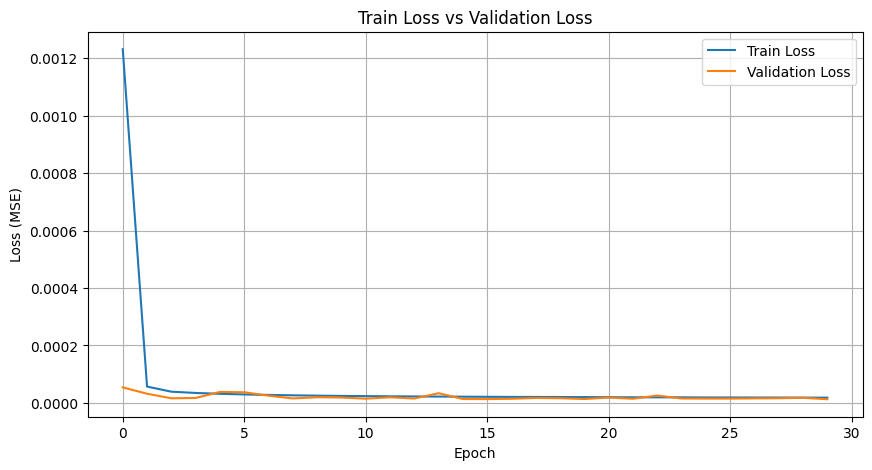

In [21]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Train Loss vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()


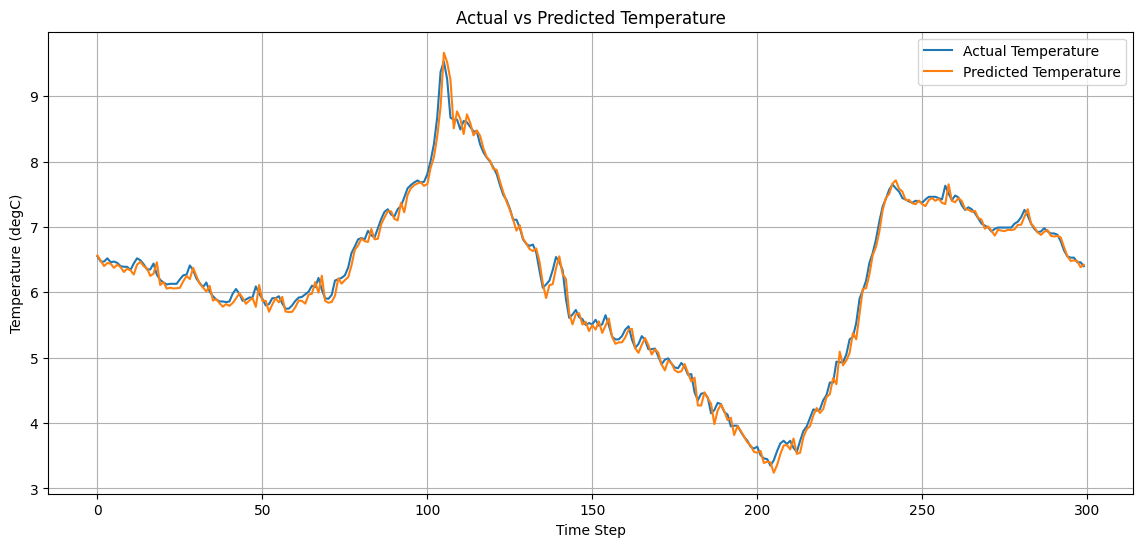

In [22]:
plt.figure(figsize=(14, 6))
plt.plot(y_true[:300], label='Actual Temperature')
plt.plot(y_pred[:300], label='Predicted Temperature')
plt.xlabel('Time Step')
plt.ylabel('Temperature (degC)')
plt.title('Actual vs Predicted Temperature')
plt.legend()
plt.grid(True)
plt.show()


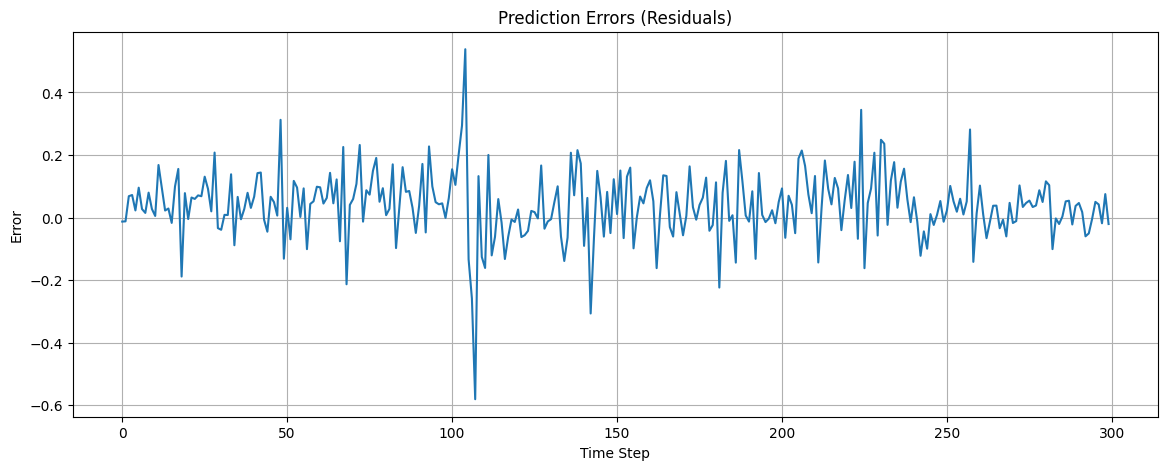

In [23]:
errors = y_true - y_pred

plt.figure(figsize=(14, 5))
plt.plot(errors[:300])
plt.xlabel('Time Step')
plt.ylabel('Error')
plt.title('Prediction Errors (Residuals)')
plt.grid(True)
plt.show()

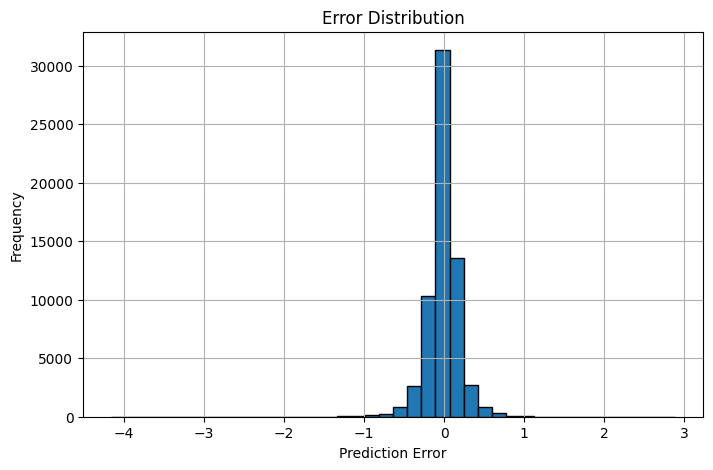

In [24]:
plt.figure(figsize=(8, 5))
plt.hist(errors, bins=40, edgecolor='black')
plt.xlabel('Prediction Error')
plt.ylabel('Frequency')
plt.title('Error Distribution')
plt.grid(True)
plt.show()

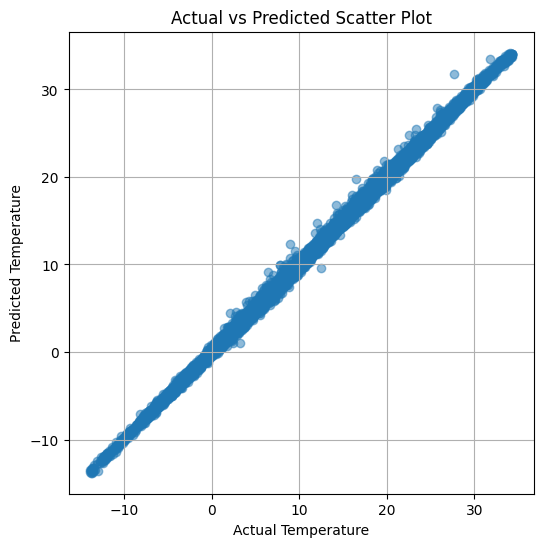

In [25]:
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.5)
plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.title("Actual vs Predicted Scatter Plot")
plt.grid(True)


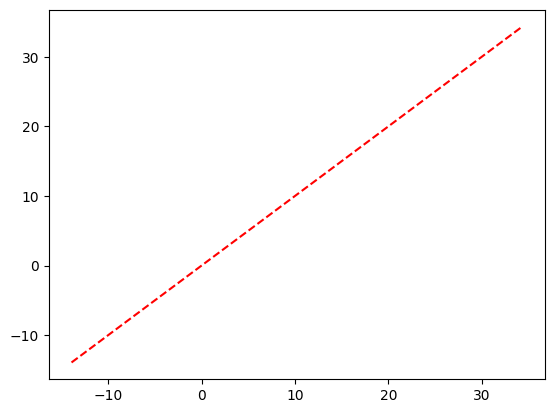

In [26]:
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')
plt.show()